# Before you start :
   - These exercises are related to the Pivot table and correlation lessons.
   - Keep in mind that you need to use some of the functions you learned in the previous lessons.
   - All datasets are provided in the `your-code` folder of this lab.
   - Elaborate your codes and outputs as much as you can.
   - Try your best to answer the questions and complete the tasks and most importantly enjoy the process!!!

#### Import all the libraries that are necessary

In [86]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Challenge 1

#### Open the ` Employee.csv` file and name your dataset `employee`

In [3]:
employee = pd.read_csv(r"data\Employee.csv")

In [4]:
employee

,Name,Department,Education,Gender,Title,Years,Salary
0,Jose,IT,Bachelor,M,analyst,1,35
1,Maria,IT,Master,F,analyst,2,30
2,David,HR,Master,M,analyst,2,30
3,Sonia,HR,Bachelor,F,analyst,4,35
4,Samuel,Sales,Master,M,associate,3,55
5,Eva,Sales,Bachelor,F,associate,2,55
6,Carlos,IT,Master,M,VP,8,70
7,Pedro,IT,Phd,M,associate,7,60
8,Ana,HR,Master,F,VP,8,70


#### What's the mean salary by department. 
##### Tip : There are 2 ways to do it - one way is with and the other way is without pivot tables. Do it both ways. 


In [5]:
employee[["Department", "Salary"]].groupby("Department").mean()

,Salary
Department,
HR,45.00
IT,48.75
Sales,55.00


In [6]:
employee.pivot_table("Salary", "Department")

,Salary
Department,
HR,45.00
IT,48.75
Sales,55.00


#### We want now to group the data by more than one column. Use Pandas pivot table function to select the mean salary by department and title

In [7]:
employee.pivot_table("Salary", ["Department", "Title"])

Salary
Department Title            
HR         VP           70.0
           analyst      32.5
IT         VP           70.0
           analyst      32.5
           associate    60.0
Sales      associate    55.0

#### We want to display the number of years of work experience and the salary for each Title. Add Years as a column in your pivot table
*Hint: Use Pandas doc(see References in README.md) to explore the pivot_table() arguments*

In [8]:
employee.pivot_table(["Salary", "Years"], ["Department", "Title"])

Salary  Years
Department Title                   
HR         VP           70.0    8.0
           analyst      32.5    3.0
IT         VP           70.0    8.0
           analyst      32.5    1.5
           associate    60.0    7.0
Sales      associate    55.0    2.5

#### We want to know the information about the mean salary and number of employees in each department and for each job title

In [9]:
employee

,Name,Department,Education,Gender,Title,Years,Salary
0,Jose,IT,Bachelor,M,analyst,1,35
1,Maria,IT,Master,F,analyst,2,30
2,David,HR,Master,M,analyst,2,30
3,Sonia,HR,Bachelor,F,analyst,4,35
4,Samuel,Sales,Master,M,associate,3,55
5,Eva,Sales,Bachelor,F,associate,2,55
6,Carlos,IT,Master,M,VP,8,70
7,Pedro,IT,Phd,M,associate,7,60
8,Ana,HR,Master,F,VP,8,70


In [10]:
employee.pivot_table(["Salary", "Name"], ["Department", "Title"], aggfunc={"Salary": "mean", "Name": "count"})

Name  Salary
Department Title                  
HR         VP            1    70.0
           analyst       2    32.5
IT         VP            1    70.0
           analyst       2    32.5
           associate     1    60.0
Sales      associate     2    55.0

#### We want to know for each department and for each job title the Salary's median,minimum,maximum and standard deviation. Comment your results

In [11]:
# your answer here
employee_stats = employee.pivot_table(values="Salary", index=["Department", "Title"], aggfunc=["median", "min", "max", "std"])

#### Based on your comments, fill the missing values with an appropriate value

In [12]:
# your answer here
employee_stats.fillna(0)

median    min    max       std
                     Salary Salary Salary    Salary
Department Title                                   
HR         VP          70.0     70     70  0.000000
           analyst     32.5     30     35  3.535534
IT         VP          70.0     70     70  0.000000
           analyst     32.5     30     35  3.535534
           associate   60.0     60     60  0.000000
Sales      associate   55.0     55     55  0.000000

#### The stake holders want to know for each department the number of employees and how much money is spend on salaries. Could you provide that information? 

In [13]:
employee.groupby("Department").agg({"Name": "count", "Salary": "sum"}).rename(columns={"Name": "Number of Employees", "Salary": "Total Salary"})

,Number of Employees,Total Salary
Department,,
HR,3,135
IT,4,195
Sales,2,110


#### For each Department and Title, we want to know the the total years of work experience and the mean salary

In [14]:
employee.pivot_table(values=["Years", "Salary"], index=["Department", "Title"], aggfunc={"Years": "sum", "Salary": "mean"})

Salary  Years
Department Title                   
HR         VP           70.0      8
           analyst      32.5      6
IT         VP           70.0      8
           analyst      32.5      3
           associate    60.0      7
Sales      associate    55.0      5

#### Bonus

#### We now want to compute the mean salary after removing the maxima for each Department. Create the appropriate pivot table

#### * Hint: Write a custom function*

In [72]:
def mean_excluding_max(series):
    return series[series != series.max()].mean()

employee.pivot_table(values="Salary", index="Department", aggfunc=mean_excluding_max)

,Salary
Department,
HR,32.500000
IT,41.666667


# Challenge 2

#### Open the ` Fitbit.csv` file and name your dataset `fitbit`

In [117]:
fitbit = pd.read_csv(r"data\Fitbit.csv")

#### Explore you dataset in terms of data types and descriptive statistics
#### *Hint: Use Pandas functions from previous lectures*

In [75]:
fitbit.head()

,Date,Calorie burned,Steps,Distance,Floors,Minutes Sedentary,Minutes Lightly Active,Minutes Fairly Active,Minutes Very Active,Activity Calories,MinutesOfSleep,MinutesOfBeingAwake,NumberOfAwakings,LengthOfRestInMinutes
0,08-05-2015,1934,905,0.65,0,1.355,46,0,0,1680,384,26,23,417
1,09-05-2015,3631,18925,14.11,4,611.000,316,61,60,2248,454,35,21,491
2,10-05-2015,3204,14228,10.57,1,602.000,226,14,77,1719,387,46,25,436
3,11-05-2015,2673,6756,5.02,8,749.000,190,23,4,9620,311,31,21,350
4,12-05-2015,2495,502,3.73,1,876.000,171,0,0,7360,407,65,44,491


In [74]:
fitbit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 367 entries, 0 to 366
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Date                    367 non-null    object 
 1   Calorie burned          367 non-null    int64  
 2   Steps                   367 non-null    int64  
 3   Distance                367 non-null    float64
 4   Floors                  367 non-null    int64  
 5   Minutes Sedentary       367 non-null    float64
 6   Minutes Lightly Active  367 non-null    int64  
 7   Minutes Fairly Active   367 non-null    int64  
 8   Minutes Very Active     367 non-null    int64  
 9   Activity Calories       367 non-null    int64  
 10  MinutesOfSleep          367 non-null    int64  
 11  MinutesOfBeingAwake     367 non-null    int64  
 12  NumberOfAwakings        367 non-null    int64  
 13  LengthOfRestInMinutes   367 non-null    int64  
dtypes: float64(2), int64(11), object(1)
memory

In [77]:
fitbit.isnull().sum()

Date                      0
Calorie burned            0
Steps                     0
Distance                  0
Floors                    0
Minutes Sedentary         0
Minutes Lightly Active    0
Minutes Fairly Active     0
Minutes Very Active       0
Activity Calories         0
MinutesOfSleep            0
MinutesOfBeingAwake       0
NumberOfAwakings          0
LengthOfRestInMinutes     0
dtype: int64

In [80]:
fitbit.duplicated().sum()

0

In [81]:
fitbit.describe()

,Calorie burned,Steps,Distance,Floors,Minutes Sedentary,Minutes Lightly Active,Minutes Fairly Active,Minutes Very Active,Activity Calories,MinutesOfSleep,MinutesOfBeingAwake,NumberOfAwakings,LengthOfRestInMinutes
count,367.000000,367.000000,367.000000,367.000000,367.000000,367.000000,367.000000,367.000000,367.000000,367.000000,367.000000,367.000000,367.000000
mean,2741.501362,10121.588556,8.549128,11.724796,563.934482,236.405995,26.163488,35.722071,2044.147139,290.479564,28.008174,16.196185,321.343324
std,916.307036,5594.836225,3.409881,10.337370,294.793145,86.531376,20.319456,31.006682,2041.267168,154.752328,18.541415,10.757622,170.786726
min,179.000000,0.000000,0.000000,0.000000,1.002000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2698.000000,6730.500000,6.155000,5.000000,520.000000,179.000000,8.000000,10.500000,1218.500000,224.000000,14.000000,7.000000,248.000000
50%,2974.000000,10413.000000,8.290000,11.000000,663.000000,226.000000,24.000000,29.000000,1553.000000,337.000000,29.000000,16.000000,370.000000
75%,3233.000000,13916.500000,10.560000,16.000000,756.500000,290.000000,41.500000,54.000000,1927.500000,400.500000,41.500000,24.000000,440.500000
max,4351.000000,26444.000000,20.450000,101.000000,998.000000,472.000000,101.000000,153.000000,9830.000000,553.000000,78.000000,45.000000,607.000000


#### You suspect that there must be a linear relationship between the Minutes Very Active and the Steps. Compute the correlation between these variables.

In [83]:
# your answer here
fitbit[["Minutes Very Active", "Steps"]].corr()

,Minutes Very Active,Steps
Minutes Very Active,1.000000,0.571452
Steps,0.571452,1.000000


#### Use matplotlib to visually plot Minutes Very active vs Steps. 

##### Hint : import matplotlib.pyplot as plt (See previous lessons)#####
- Use plt.scatter(x=df['col_name_1'], y=df['col_name_2'])

<Axes: xlabel='Steps', ylabel='Minutes Very Active'>

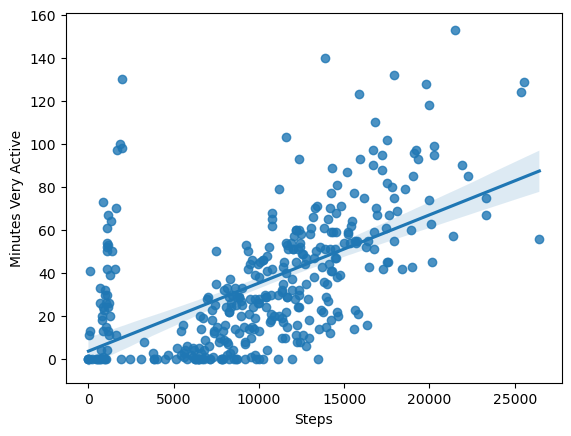

In [90]:
sns.regplot(fitbit, x="Steps", y="Minutes Very Active")

#### What can you say about Minute Very Active and Steps? Write a comment below

In [22]:
# your comment here

#### We also suspect that there must be a linear relationship between the Minutes Sedentary and the Steps. Compute the correlation between these variables.

In [124]:
#Fix 'Minutes Sedentary' by assuming values < 10 are misparsed (e.g., 1.355 -> 1355)
fitbit['Minutes Sedentary'] = fitbit['Minutes Sedentary'].apply(
    lambda x: int(str(x).replace('.', '')) if x < 10 else int(x)
)

# Check the result
display(fitbit)

,Date,Calorie burned,Steps,Distance,Floors,Minutes Sedentary,Minutes Lightly Active,Minutes Fairly Active,Minutes Very Active,Activity Calories,MinutesOfSleep,MinutesOfBeingAwake,NumberOfAwakings,LengthOfRestInMinutes
0,08-05-2015,1934,905,0.65,0,1355,46,0,0,1680,384,26,23,417
1,09-05-2015,3631,18925,14.11,4,611,316,61,60,2248,454,35,21,491
2,10-05-2015,3204,14228,10.57,1,602,226,14,77,1719,387,46,25,436
3,11-05-2015,2673,6756,5.02,8,749,190,23,4,9620,311,31,21,350
4,12-05-2015,2495,502,3.73,1,876,171,0,0,7360,407,65,44,491
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
362,03-05-2016,3796,18588,14.13,16,599,275,49,79,236,377,33,18,410
363,04-05-2016,3525,16382,12.39,16,684,333,10,55,2075,406,21,8,427
364,05-05-2016,3649,21913,16.40,19,701,287,29,90,2249,280,35,15,315
365,06-05-2016,3539,19023,14.79,15,575,298,8,85,2112,370,42,22,412


In [126]:
# your answer here
fitbit[["Minutes Sedentary", "Steps"]].corr()

,Minutes Sedentary,Steps
Minutes Sedentary,1.000000,-0.202853
Steps,-0.202853,1.000000


#### Use matplotlib to visually plot Minutes Sedentary vs Steps. Based on the results of the computed correlation and the plot. What can you say about these 2 variables?

<Axes: xlabel='Minutes Sedentary', ylabel='Steps'>

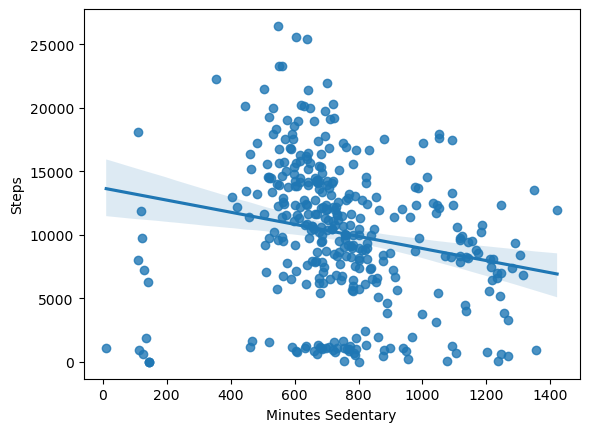

In [125]:
# your answer here
sns.regplot(fitbit, x="Minutes Sedentary", y="Steps")

#### We also suspect that there must be a linear relationship between the MinutesOfSleep and the Steps. Compute the correlation between these variables.

In [127]:
fitbit[["MinutesOfSleep", "Steps"]].corr()

,MinutesOfSleep,Steps
MinutesOfSleep,1.000000,0.130986
Steps,0.130986,1.000000


#### Use matplotlib to visually plot MinutesOfSleep vs Steps. Based on the results of the computed correlation and the plot. What can you say about these 2 variables?

<Axes: xlabel='MinutesOfSleep', ylabel='Steps'>

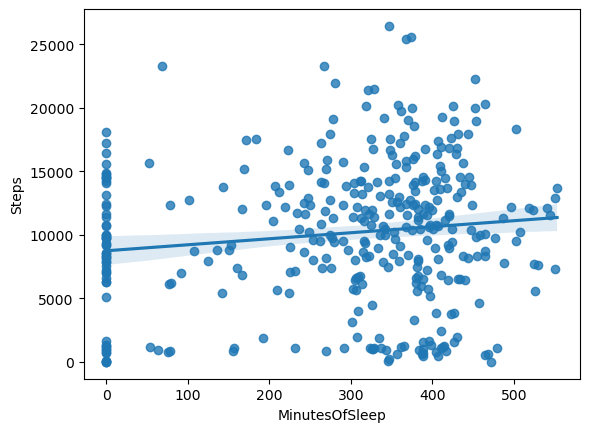

In [128]:
# your answer here
sns.regplot(fitbit, x="MinutesOfSleep", y="Steps")

#### Select a subset of your dataset with the columns below and compute the correlation matrix. Save the results in the variable `cor_fit`
column= ['Calorie burned', 'Steps','Floors','Minutes Sedentary','Minutes Very Active', 'MinutesOfSleep']

In [132]:
# your answer here
column= ['Calorie burned', 'Steps','Floors','Minutes Sedentary','Minutes Very Active', 'MinutesOfSleep']
cor_fit = fitbit[column].corr()

In [133]:
display(cor_fit)

,Calorie burned,Steps,Floors,Minutes Sedentary,Minutes Very Active,MinutesOfSleep
Calorie burned,1.000000,0.255305,0.130757,-0.067870,0.197881,0.011485
Steps,0.255305,1.000000,0.306511,-0.202853,0.571452,0.130986
Floors,0.130757,0.306511,1.000000,-0.000022,0.399503,0.069464
Minutes Sedentary,-0.067870,-0.202853,-0.000022,1.000000,-0.119247,0.002199
Minutes Very Active,0.197881,0.571452,0.399503,-0.119247,1.000000,0.108018
MinutesOfSleep,0.011485,0.130986,0.069464,0.002199,0.108018,1.000000


#### Based on the result of the correlation matrix. What are the highly correlated features with the variable Steps?
*Hint: From the results above select the variable Steps and order your results in descending order (use Pandas sort_values function)*

In [134]:
# your answer here
cor_fit.unstack().sort_values(ascending=False).drop_duplicates()

Calorie burned       Calorie burned         1.000000
Steps                Minutes Very Active    0.571452
Minutes Very Active  Floors                 0.399503
Floors               Steps                  0.306511
Steps                Calorie burned         0.255305
Calorie burned       Minutes Very Active    0.197881
Steps                MinutesOfSleep         0.130986
Floors               Calorie burned         0.130757
MinutesOfSleep       Minutes Very Active    0.108018
Floors               MinutesOfSleep         0.069464
MinutesOfSleep       Calorie burned         0.011485
                     Minutes Sedentary      0.002199
Floors               Minutes Sedentary     -0.000022
Calorie burned       Minutes Sedentary     -0.067870
Minutes Very Active  Minutes Sedentary     -0.119247
Minutes Sedentary    Steps                 -0.202853
dtype: float64

# Challenge 3

#### Open the `Time_Grades.csv` file and name your dataset `time_grades`

In [135]:
# your answer here
time_grades = pd.read_csv(r"data\Time_Grades.csv")

In [136]:
#Print time_grades
time_grades

,Name,Study time,Grade
0,Jose,4,4
1,Maria,9,7
2,David,8,9
3,Sonia,10,7
4,Samuel,20,9
5,Eva,5,3
6,Carlos,12,7
7,Pedro,6,5
8,Ana,18,9
9,Gervasio,7,3


#### Show visually the frequency distribution of the time_grades dataset.

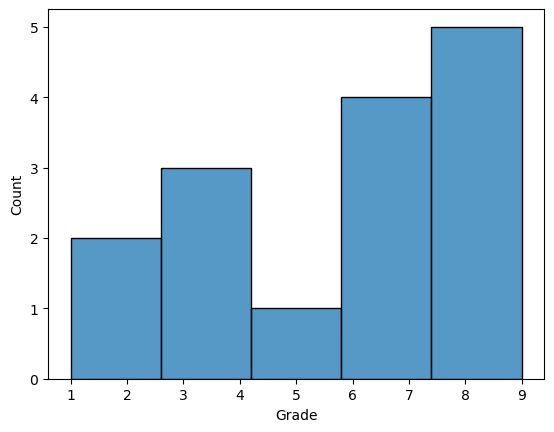

In [142]:
sns.histplot(time_grades, x="Grade")
plt.show()

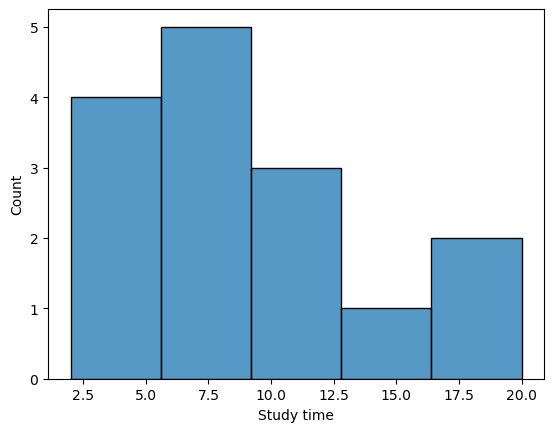

In [ ]:
# your answer here
sns.histplot(time_grades, x="Study time")
plt.show()

<Axes: xlabel='Study time', ylabel='Grade'>

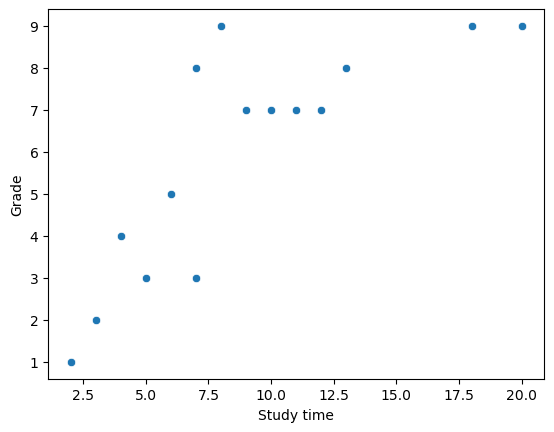

In [143]:
sns.scatterplot(time_grades, x="Study time", y="Grade")

#### Is there a correaltion between study time and Grade? Use both Pearson and Spearman correlation and comment your results.

In [144]:
# your answer here-Pearson 
time_grades[["Study time", "Grade"]].corr(method="pearson")

,Study time,Grade
Study time,1.000000,0.798046
Grade,0.798046,1.000000


In [146]:
## your answer here-Spearman
time_grades[["Study time", "Grade"]].corr(method="spearman")

,Study time,Grade
Study time,1.000000,0.819659
Grade,0.819659,1.000000


#### Use matplotlib to visually plot Study time vs Grade. Based on the results of the computed correlation and the plot. What can you say about these 2 variables?

<Axes: xlabel='Study time', ylabel='Grade'>

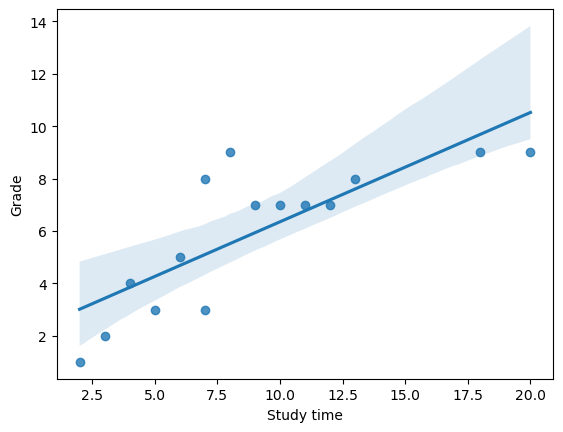

In [147]:
# your answer here
sns.regplot(time_grades, x="Study time", y="Grade")

In [37]:
#your comment here